# Reading the saved dictionary

In [9]:
import pickle
#new_dict.pkl is for training set
#new_dict_val.pkl is for validation set
with open('new_dict.pkl', 'rb') as f:
    supp_dict = pickle.load(f)

In [ ]:
# these keys are not present in this dict (in training support)
# ignore_keys = [3, 11, 29, 53, 84, 88, 94, 123, 128, 135, 143, 158, 160, 162, 170, 176, 179, 193, 198, 199, 210, 220, 221]

In [10]:
len(supp_dict) #211 number of parts so 211 + 23 = 234 and for Validation it is 207 + ? = 234

211

In [3]:
supp_dict[0].keys()

dict_keys(['image_name', 'image', 'obj_id', 'obj_mask', 'part_id', 'part_mask'])

In [4]:
supp_dict[0]['image_name'], supp_dict[0]['obj_id'], supp_dict[0]['part_id']

('ADE_frame_00000015', 27, 0)

## Visualizing the Supports kept in supp_dict

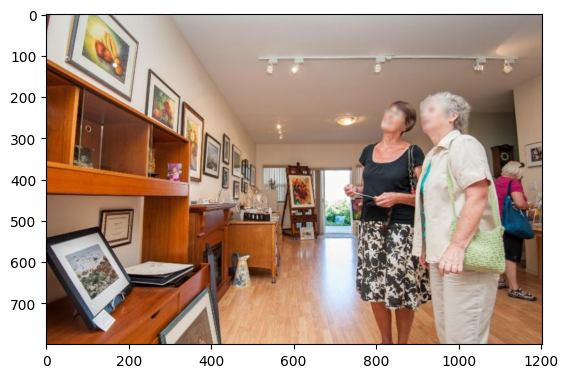

In [5]:
import matplotlib.pyplot as plt

plt.imshow(supp_dict[0]['image'][:, :, [2,1,0]])


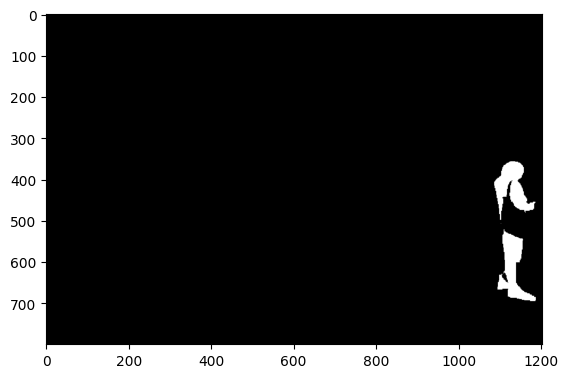

In [11]:
plt.imshow(supp_dict[0]['obj_mask'], cmap='gray')

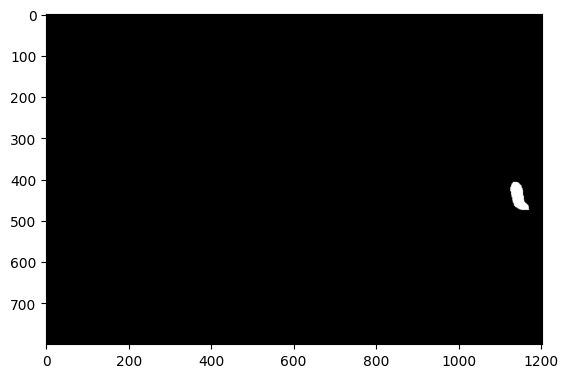

In [12]:
plt.imshow(supp_dict[0]['part_mask'], cmap='gray')

# Reading the query set from training_data

In [13]:
import os 
# root_dir, dataset_root
root_dir = "data/training_data_MOHAN"
#root_dir = "data/testing_data_MOHAN"

folder_names = os.listdir(root_dir)
len(folder_names)

4319

In [14]:
folder_paths = [os.path.join(root_dir, folder) for folder in folder_names]
len(folder_paths)

4319

In [15]:
folder_path = folder_paths[11]
folder_name = os.path.basename(folder_path)
folder_name

'ADE_train_00006840_27_5'

In [16]:
parts = folder_name.split('_')
object_id = int(parts[-2])
part_id = int(parts[-1])
parts, object_id, part_id

(['ADE', 'train', '00006840', '27', '5'], 27, 5)

In [17]:
import matplotlib.pyplot as plt

In [18]:
from PIL import Image
# Load image and masks
query_image = Image.open(os.path.join(folder_path, 'image.jpg')).convert("RGB")
query_full_mask = Image.open(os.path.join(folder_path, 'object_mask.png')).convert("L")
query_part_mask = Image.open(os.path.join(folder_path, 'part_mask.png')).convert("L")

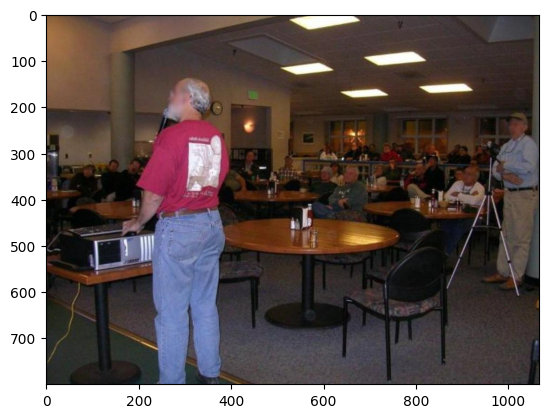

In [19]:
plt.imshow(query_image)

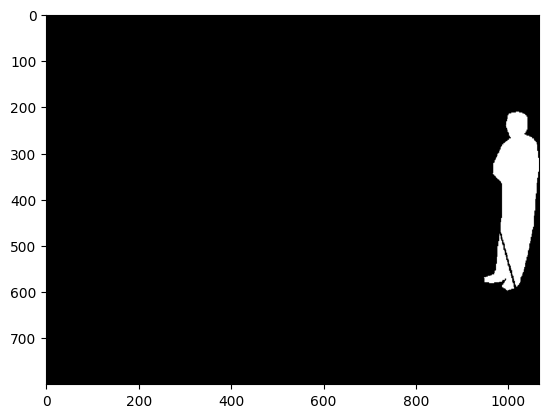

In [20]:
plt.imshow(query_full_mask, cmap='gray')

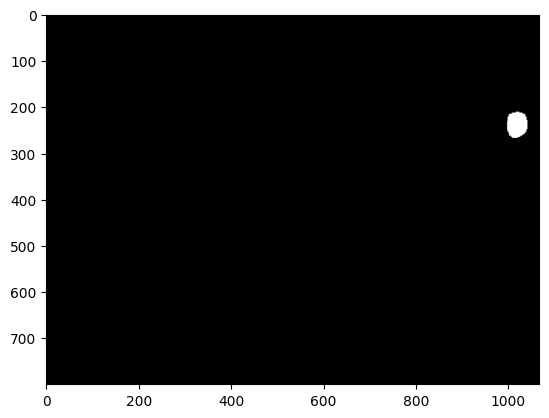

In [21]:
plt.imshow(query_part_mask, cmap='gray')

# Writin the above code for all the data with class

In [22]:
from torch.utils.data import DataLoader
from dataset import PartQueryDataset, custom_transform

# root directory pointing to training_data
dataset_root = "data/training_data_MOHAN"
#dataset_root = "data/testing_data_MOHAN"

# supp_dict is defined above

dataset = PartQueryDataset(root_dir=dataset_root, supp_dict=supp_dict, transform=custom_transform)
#with now transform applied
#dataset = PartQueryDataset(dataset_root, supp_dict)

len(dataset)

4319

In [23]:
dataset[0].keys()

dict_keys(['query_image', 'query_full_mask', 'query_part_mask', 'object_id', 'part_id', 'support_image', 'support_full_mask', 'support_part_mask'])

In [24]:
import matplotlib.pyplot as plt

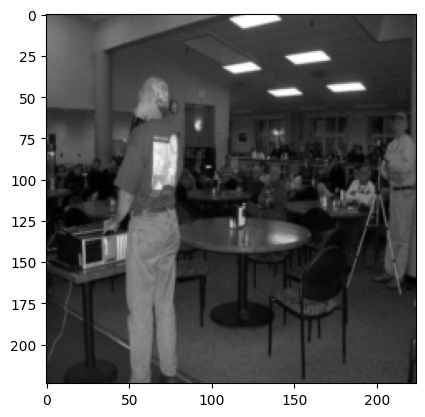

In [25]:
# when now transform applied then call below because it return tensor
#plt.imshow(dataset[0]['query_image'].permute(1, 2, 0).cpu().numpy())

#when transform used, use below code as it returns numpy of shape 224*224
plt.imshow(dataset[11]['query_image'], cmap='gray')

In [26]:
dataset[11]['query_full_mask'].shape, type(dataset[11]['query_full_mask'])

((224, 224), numpy.ndarray)

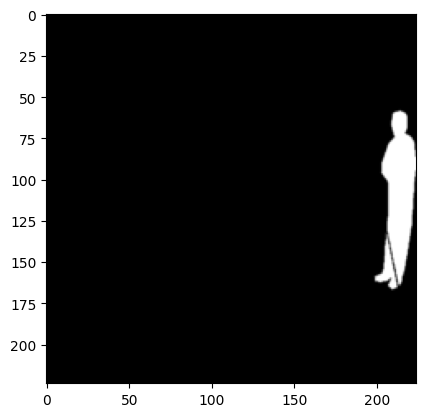

In [27]:
#use when no transform is applied
#plt.imshow(dataset[0]['query_full_mask'].squeeze(0), cmap='gray')

plt.imshow(dataset[11]['query_full_mask'], cmap='gray')

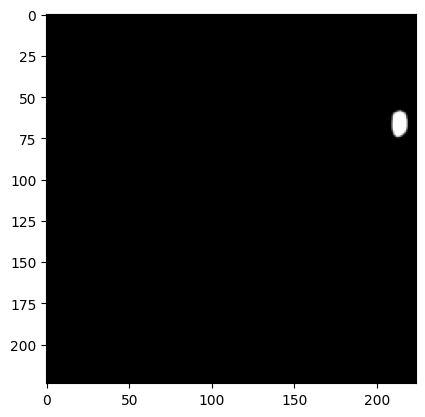

In [28]:
# plt.imshow(dataset[0]['query_part_mask'].squeeze(0), cmap='gray')

plt.imshow(dataset[11]['query_part_mask'], cmap='gray')

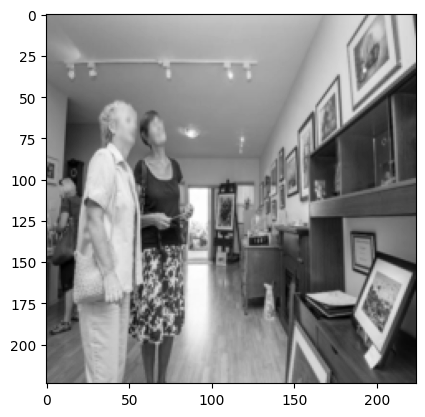

In [29]:
# here the image is not a tensor it is an mumpy array so just use this [2, 1, 0] to convert from BGR to RGB
# how ever use this when no transform is applied
# plt.imshow(dataset[0]['support_image'][:, :, [2, 1, 0]])

plt.imshow(dataset[11]['support_image'], cmap='gray')

In [30]:
dataset[11]['support_full_mask'].shape, type(dataset[11]['support_full_mask'])

((224, 224), numpy.ndarray)

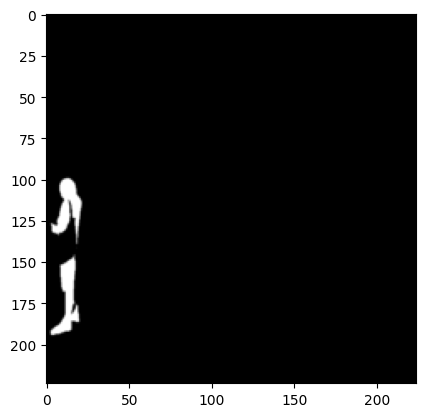

In [31]:
plt.imshow(dataset[11]['support_full_mask'], cmap='gray')

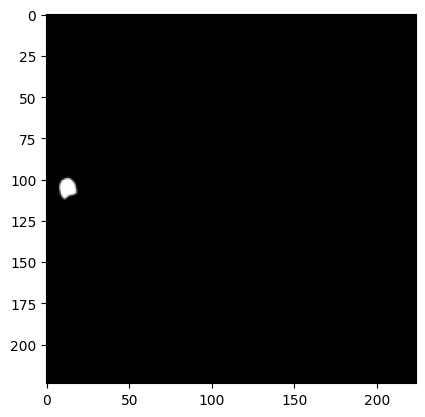

In [32]:
plt.imshow(dataset[11]['support_part_mask'], cmap='gray')

In [29]:
# below code is to check if max of my mask is at 0 or not
# Get unique values and their counts
# import numpy as np
# unique_values, counts = np.unique(dataset[0]['support_full_mask'], return_counts=True)

# # Display results
# count_all = 0
# for value, count in zip(unique_values, counts):
#     print(f"Value {value} occurs {count} times.")
#     count_all += 1

# print(count_all)

In [33]:
dataloader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=4)

In [34]:
# now i have support and query
# Iterate over data
for batch in dataloader:
    print("Query image shape:", batch["query_image"].shape)            # (BS, 224, 224)
    print("Support image shape:", batch["support_image"].shape)        # (BS, 224, 224)
    print("Object ID:", batch["object_id"])
    print("Part ID:", batch["part_id"])
    break  # just show one for now

Query image shape: torch.Size([8, 224, 224])
Support image shape: torch.Size([8, 224, 224])
Object ID: tensor([ 9, 21, 13,  2, 21, 32, 18, 23])
Part ID: tensor([ 60,  37, 110,  68,  33,  26,  97, 155])


In [35]:
batch['query_part_mask'].shape

torch.Size([8, 224, 224])

# getting the features for query and affinity matrix

In [37]:
from part_seg import get_query_feature_and_affinity_matrix
import numpy as np
import os

In [38]:
# Ensure the directory exists
output_dir = './saved_features'
os.makedirs(output_dir, exist_ok=True)

In [ ]:
# argument passing sequence
#support_image, support_mask, support_full_mask, query_image, query_full_mask, query_part_mask

In [39]:
# for single batch_size
count = 0
for batch in dataloader:

    # the below code is to get the 11th item
    if count == 0:
        count += 1
        continue
       
    for i in range(len(batch['query_image'])):
        query_dict, support_dict, query_full_superpixels, support_part_superpixels, gt_query_part_superpixels, cos_mat_dist = get_query_feature_and_affinity_matrix(batch["support_image"][i], batch["support_part_mask"][i], 
                                                                                                     batch["support_full_mask"][i], 
                                                                                                     batch["query_image"][i], batch["query_part_mask"][i], 
                                                                                                     batch["query_full_mask"][i])
        
        # Save the outputs
        save_path = f"./saved_features/item_{i+11}.npz"
        np.savez_compressed(save_path, 
                            query_dict=query_dict, 
                            support_dict=support_dict,
                            query_full_superpixels=query_full_superpixels,
                            support_part_superpixels=support_part_superpixels,
                            gt_query_part_superpixels=gt_query_part_superpixels, 
                            cos_mat_dist=cos_mat_dist)
        
        print(f"Saved features to {save_path}")
        
        break # just to print one element in the batch
        
    break #to just print first batch

Saved features to ./saved_features/item_11.npz


In [9]:
query_dict['original_image'].shape, query_dict['superpixel_overlayed'].shape, query_dict['superpixel_labels'].shape, query_dict['superpixel_features'].shape

((224, 224, 3), (224, 224, 3), (224, 224), (784, 1024))

In [41]:
support_dict['original_image'].shape, support_dict['superpixel_overlayed'].shape, support_dict['superpixel_labels'].shape, support_dict['superpixel_features'].shape

((224, 224, 3), (224, 224, 3), (224, 224), (784, 1024))

In [ ]:
import numpy as np
len(np.unique(query_dict['superpixel_labels'])) #784 is the number of superpixel our entire image is divided into

784

In [43]:
import numpy as np
len(np.unique(support_dict['superpixel_labels']))

784

In [45]:
len(query_full_superpixels), type(query_full_superpixels), cos_mat_dist.shape

(22, numpy.ndarray, (22, 4))

In [46]:
len(support_part_superpixels), type(support_part_superpixels), cos_mat_dist.shape

(4, numpy.ndarray, (22, 4))

In [47]:
len(gt_query_part_superpixels), type(gt_query_part_superpixels), cos_mat_dist.shape

(4, numpy.ndarray, (22, 4))

In [48]:
# pick only superpixel belonging to query object
query_dict['superpixel_features'][query_full_superpixels].shape

(22, 1024)

In [49]:
query_full_superpixels

array([303, 304, 305, 306, 331, 332, 333, 359, 360, 361, 387, 388, 389,
       416, 418, 444, 445, 471, 472, 473, 500, 502], dtype=int32)

In [50]:
support_part_superpixels

array([450, 479, 480, 507], dtype=int32)

In [51]:
gt_query_part_superpixels

array([471, 472, 473, 502], dtype=int32)

In [ ]:
# we can load .npz file from ./saved_features and can work on it.
# for graph Data, we need to further make it in Graph structure that is done in image2graph.ipynb and img2graph.py

# below code is compatible for batch

In [ ]:
batch_count = 0
for batch in dataloader:
    batch_count += 1
    gt_output_list = []
    real_sups_seg_list = []
    cos_mat_dist_list = []

    for i in range(len(batch["query_image"])):
        gt_output, real_sups_seg, real_sups_seg_part, cos_mat_dist = get_query_feature_and_affinity_matrix(
            batch["support_image"][i], batch["support_part_mask"][i],
            batch["support_full_mask"][i], batch["query_image"][i],
            batch["query_part_mask"][i], batch["query_full_mask"][i]
        )
        print(f"For batch no {batch_count} the {i}th elements:")
        print(gt_output['original_image'].shape, gt_output['superpixel_overlayed'].shape, gt_output['superpixel_labels'].shape, gt_output['superpixel_features'].shape)
        print(len(real_sups_seg), cos_mat_dist.shape)
        print(len(real_sups_seg_part), cos_mat_dist.shape)
        print(gt_output['superpixel_features'][real_sups_seg].shape)
        print("\n")


        gt_output_list.append(gt_output)
        real_sups_seg_list.append(real_sups_seg)
        cos_mat_dist_list.append(cos_mat_dist)

    #break  # testing only the first batch

    if batch_count == 2:
        break

    # need to write the code to save all batches above one just appended images in a batch



For batch no 1 the 0th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
20 (20, 4)
4 (20, 4)
(20, 1024)


For batch no 1 the 1th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
41 (41, 6)
6 (41, 6)
(41, 1024)


For batch no 1 the 2th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
19 (19, 4)
4 (19, 4)
(19, 1024)


For batch no 1 the 3th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
139 (139, 12)
12 (139, 12)
(139, 1024)


For batch no 1 the 4th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
9 (9, 3)
3 (9, 3)
(9, 1024)


For batch no 1 the 5th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
22 (22, 8)
8 (22, 8)
(22, 1024)


For batch no 1 the 6th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
28 (28, 5)
5 (28, 5)
(28, 1024)


For batch no 1 the 7th elements:
(224, 224, 3) (224, 224, 3) (224, 224) (784, 1024)
15 (15, 12)
12 (15, 12)
(15, 1024)


For batch no 1 the 8th elements:
(224, 224, 3) (22

In [64]:
real_sups_seg_list[0], len(real_sups_seg_list[0])

(array([195, 220, 222, 223, 249, 250, 251, 277, 278, 279, 306, 307, 332,
        333, 334, 335, 361, 362, 363, 389, 390, 391, 417, 418, 419, 445,
        446, 447, 473, 474, 475, 501, 502, 503, 528, 529, 530, 531, 556,
        557, 558, 559, 584, 585], dtype=int32),
 44)

In [62]:
len(gt_output_list), len(real_sups_seg_list), len(cos_mat_dist_list)

(11, 11, 11)

In [ ]:
# consider these two query_superpixel_features.shape, affinity_matrix.shape and form the graph


### Modeling min_cut_pool

In [1]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import dense_mincut_pool
from torch_geometric.data import Data
import numpy as np
import os
import matplotlib.pyplot as plt

from torch_geometric.nn import GCNConv
from torch_geometric.utils import dense_to_sparse

In [24]:
def compute_supervised_loss(pred_logits, superpixel_labels, query_indices, part_mask):
    """
    Args:
        pred_logits: shape [1, N_q, 2] → output of model
        superpixel_labels: shape [H, W]
        query_indices: List of N_q superpixel indices
        part_mask: shape [H, W], binary (0/1)

    Returns:
        supervised loss (torch scalar)
    """
    device = pred_logits.device
    pred_logits = pred_logits.squeeze(0)  # [N_q, 2]

    # Prepare GT labels
    gt_labels = []
    for sp in query_indices:
        mask = (superpixel_labels == sp)
        label = (part_mask[mask].float().mean() > 0.5).long()  # 1 if >50% of superpixel is part
        gt_labels.append(label)

    gt_labels = torch.tensor(gt_labels, device=device)

    # Use cross entropy loss
    ce_loss = torch.nn.CrossEntropyLoss()
    return ce_loss(pred_logits, gt_labels)


In [26]:
class MinCutSegmentationGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_clusters=2):
        super().__init__()
        self.gcn1 = GCNConv(input_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, hidden_dim)
        self.assignment = Linear(hidden_dim, n_clusters)

    def forward(self, x, adj):
        # Convert dense adj to edge_index and edge_weight
        edge_index, edge_weight = dense_to_sparse(adj.squeeze(0))

        x = x.squeeze(0)  # [N, F]
        x = F.relu(self.gcn1(x, edge_index, edge_weight))
        x = F.relu(self.gcn2(x, edge_index, edge_weight))
        s = self.assignment(x)

        # Convert x and adj back to dense format for pooling
        x_dense = x.unsqueeze(0)  # [1, N, F]
        adj_dense = adj  # [1, N, N]
        s_dense = s.unsqueeze(0)  # [1, N, K]

        out, _, mc_loss, o_loss = dense_mincut_pool(x_dense, adj_dense, s_dense)
        return torch.softmax(s_dense, dim=-1), mc_loss, o_loss

def run_mincut_on_batch(batch, gt_output_list, real_sups_seg_list, cos_mat_dist_list, n_clusters=2, epochs=1, save_dir='overlay_output', model=None, optimizer=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    segmented_masks = []
    os.makedirs(save_dir, exist_ok=True)
    
    for i in range(len(batch["query_image"])):
        gt_output = gt_output_list[i]
        query_indices = real_sups_seg_list[i]
        affinity = cos_mat_dist_list[i]  # shape: [N_q, N_s]

        query_feats = gt_output['superpixel_features']
        query_img = gt_output['original_image']
        superpixel_labels = gt_output['superpixel_labels']

        query_feats = torch.tensor(query_feats, device=device).float()
        affinity = torch.tensor(affinity, device=device).float()
        indices = torch.tensor(query_indices, device=device)

        #getting the ground truth
        superpixel_labels = torch.tensor(superpixel_labels, device=device)
        part_mask = batch['query_part_mask'][i]  # Access part mask from batch
        #part_mask = torch.tensor(part_mask, device=device)
        part_mask = part_mask.clone().detach().to(device)

        x = query_feats[indices]  # shape: [N_q, 1024]
        adj = affinity @ affinity.T
        adj = (adj + adj.T) / 2.0
        adj = (adj - adj.min()) / (adj.max() - adj.min() + 1e-8)

        x = x.unsqueeze(0)      # [1, N_q, 1024]
        adj = adj.unsqueeze(0)  # [1, N_q, N_q]

        # model = MinCutSegmentationGCN(input_dim=x.shape[-1], n_clusters=n_clusters).to(device)
        # optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

        for _ in range(epochs):
            optimizer.zero_grad()
            pred_logits, mc_loss, o_loss = model(x, adj)

            #loss = mc_loss + o_loss
            supervised_loss = compute_supervised_loss(pred_logits, superpixel_labels, query_indices, part_mask)

            loss = mc_loss + o_loss + supervised_loss
            loss.backward()
            optimizer.step()

        pred_soft = pred_logits.squeeze(0)              # [N_q, n_clusters]
        pred_cluster_ids = pred_soft.argmax(dim=-1)     # [N_q]

        # Identify positive cluster
        affinity_per_cluster = []
        for c in range(n_clusters):
            cluster_mask = (pred_cluster_ids == c)
            if cluster_mask.sum() == 0:
                affinity_per_cluster.append(0.0)
            else:
                affinity_per_cluster.append(affinity[cluster_mask].mean().item())

        positive_cluster = int(np.argmax(affinity_per_cluster))
        binary_pred = (pred_cluster_ids == positive_cluster).to(torch.uint8)

        # Map superpixel-level predictions to full image mask
        full_mask = np.zeros_like(superpixel_labels.cpu().numpy(), dtype=np.uint8)
        for j, sp_idx in enumerate(query_indices):
            full_mask[superpixel_labels.cpu().numpy() == sp_idx] = binary_pred[j].item()

        segmented_masks.append(full_mask)

        # Save overlay
        overlay = (query_img.copy() * 0.5 + np.stack([full_mask*255]*3, axis=-1) * 0.5).astype(np.uint8)
        plt.imsave(os.path.join(save_dir, f"overlay_batch_{i}.png"), overlay)

    return segmented_masks


In [27]:
model = MinCutSegmentation(input_dim=1024, n_clusters=2).to('cuda')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

In [30]:
mincut_segmented_masks = []

batch_count = 0
for batch in dataloader:
    batch_count += 1
    gt_output_list = []
    real_sups_seg_list = []
    cos_mat_dist_list = []

    for i in range(len(batch["query_image"])):
        gt_output, real_sups_seg, cos_mat_dist = get_query_feature_and_affinity_matrix(
            batch["support_image"][i], batch["support_part_mask"][i],
            batch["support_full_mask"][i], batch["query_image"][i],
            batch["query_full_mask"][i]
        )

        gt_output_list.append(gt_output)
        real_sups_seg_list.append(real_sups_seg)
        cos_mat_dist_list.append(cos_mat_dist)

    # Now call the segmentation + overlay function
    seg_masks = run_mincut_on_batch(
        batch,
        gt_output_list,
        real_sups_seg_list,
        cos_mat_dist_list,
        n_clusters=2,
        epochs=300,  # Optional: change based on your needs
        save_dir='overlay_output',
        model=model,
        optimizer=optimizer
    )

    mincut_segmented_masks.extend(seg_masks)
    print(f"Batch number {batch_count} completed")
    break  # remove break to run on entire dataset


Batch number 1 completed


In [ ]:
#Save model
model_path = os.path.join('overlay_output', 'mincut_model_final.pth')
torch.save(model.state_dict(), model_path)
print(f"\nModel saved to {model_path}")

In [20]:
from torch.utils.data import DataLoader
from dataset import PartQueryDataset, custom_transform

# root directory pointing to training_data
training_dataset_root = "data/training_data_MOHAN"

# supp_dict is defined above

training_dataset = PartQueryDataset(root_dir=training_dataset_root, supp_dict=supp_dict, transform=custom_transform)
#with now transform applied
#dataset = PartQueryDataset(dataset_root, supp_dict)

len(training_dataset)

4319

In [21]:
train_dataloader = DataLoader(training_dataset, batch_size=8, shuffle=False, num_workers=4)

In [ ]:
model = MinCutSegmentation(input_dim=1024, n_clusters=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

train_model(
    dataloader=train_dataloader,
    model=model,
    optimizer=optimizer,
    n_clusters=2,
    epochs=10,  # Or however many you want
    save_dir='overlay_output'
)



## Inferencing of Test Dataset

In [ ]:
import torch
import torch.nn.functional as F
import os
import numpy as np
import matplotlib.pyplot as plt

from torch_geometric.utils import dense_to_sparse

@torch.no_grad()
def inference_on_batch(batch, gt_output_list, real_sups_seg_list, cos_mat_dist_list, model_path, n_clusters=2, save_dir='inference_output'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(save_dir, exist_ok=True)

    # Load your trained GCN-based model
    model = MinCutSegmentationGCN(input_dim=1024, n_clusters=n_clusters).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    segmented_masks = []

    for i in range(len(batch["query_image"])):
        gt_output = gt_output_list[i]
        query_indices = real_sups_seg_list[i]
        affinity = cos_mat_dist_list[i]

        query_feats = torch.tensor(gt_output['superpixel_features'], device=device).float()
        superpixel_labels = torch.tensor(gt_output['superpixel_labels'], device=device)
        query_img = gt_output['original_image']
        indices = torch.tensor(query_indices, device=device)
        affinity = torch.tensor(affinity, device=device).float()

        x = query_feats[indices]
        adj = affinity @ affinity.T
        adj = (adj + adj.T) / 2.0
        adj = (adj - adj.min()) / (adj.max() - adj.min() + 1e-8)

        x = x.unsqueeze(0)      # [1, N_q, F]
        adj = adj.unsqueeze(0)  # [1, N_q, N_q]

        # Predict cluster logits
        pred_logits, _, _ = model(x, adj)
        pred_soft = pred_logits.squeeze(0)
        pred_cluster_ids = pred_soft.argmax(dim=-1)

        # Assign positive cluster based on affinity pattern
        affinity_per_cluster = []
        for c in range(n_clusters):
            cluster_mask = (pred_cluster_ids == c)
            if cluster_mask.sum() == 0:
                affinity_per_cluster.append(0.0)
            else:
                affinity_per_cluster.append(affinity[cluster_mask].mean().item())

        positive_cluster = int(np.argmax(affinity_per_cluster))
        binary_pred = (pred_cluster_ids == positive_cluster).to(torch.uint8)

        full_mask = np.zeros_like(superpixel_labels.cpu().numpy(), dtype=np.uint8)
        for j, sp_idx in enumerate(query_indices):
            full_mask[superpixel_labels.cpu().numpy() == sp_idx] = binary_pred[j].item()

        overlay = (query_img.copy() * 0.5 + np.stack([full_mask*255]*3, axis=-1) * 0.5).astype(np.uint8)
        plt.imsave(os.path.join(save_dir, f"inference_overlay_img_{i}.png"), overlay)

        segmented_masks.append(full_mask)

    return segmented_masks


In [ ]:
# Before loop:
model_path = "path/to/mincut_model_final.pth"  # your saved model from training
save_dir = "inference_results"

# Then for each batch of test images:
inference_masks = inference_on_batch(
    batch,
    gt_output_list,
    real_sups_seg_list,
    cos_mat_dist_list,
    model_path=model_path,
    n_clusters=2,
    save_dir=save_dir
)


In [ ]:
def inference(dataloader, model_path, n_clusters=2, save_dir='inference_output'):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MinCutSegmentation(input_dim=1024, n_clusters=n_clusters).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    os.makedirs(save_dir, exist_ok=True)

    for batch_idx, batch in enumerate(dataloader):
        for i in range(len(batch["query_image"])):
            gt_output, real_sups_seg, cos_mat_dist = get_query_feature_and_affinity_matrix(
                batch["support_image"][i], batch["support_part_mask"][i],
                batch["support_full_mask"][i], batch["query_image"][i],
                batch["query_full_mask"][i]
            )
            query_feats = gt_output['superpixel_features']
            query_img = gt_output['original_image']
            superpixel_labels = gt_output['superpixel_labels']
            indices = real_sups_seg
            affinity = cos_mat_dist

            query_feats = torch.tensor(query_feats, device=device).float()
            affinity = torch.tensor(affinity, device=device).float()
            indices = torch.tensor(indices, device=device)
            superpixel_labels = torch.tensor(superpixel_labels, device=device)

            x = query_feats[indices]
            adj = affinity @ affinity.T
            adj = (adj + adj.T) / 2.0
            adj = (adj - adj.min()) / (adj.max() - adj.min() + 1e-8)

            x = x.unsqueeze(0)
            adj = adj.unsqueeze(0)

            with torch.no_grad():
                pred_logits, _, _ = model(x, adj)
                pred_soft = pred_logits.squeeze(0)
                pred_cluster_ids = pred_soft.argmax(dim=-1)

            affinity_per_cluster = []
            for c in range(n_clusters):
                cluster_mask = (pred_cluster_ids == c)
                if cluster_mask.sum() == 0:
                    affinity_per_cluster.append(0.0)
                else:
                    affinity_per_cluster.append(affinity[cluster_mask].mean().item())
            positive_cluster = int(np.argmax(affinity_per_cluster))
            binary_pred = (pred_cluster_ids == positive_cluster).to(torch.uint8)

            full_mask = np.zeros_like(superpixel_labels.cpu().numpy(), dtype=np.uint8)
            for j, sp_idx in enumerate(indices):
                full_mask[superpixel_labels.cpu().numpy() == sp_idx] = binary_pred[j].item()
            overlay = (query_img.copy() * 0.5 + np.stack([full_mask*255]*3, axis=-1) * 0.5).astype(np.uint8)
            plt.imsave(os.path.join(save_dir, f"inference_batch_{batch_idx}_img_{i}.png"), overlay)

    print("\nInference complete and results saved.")

In [ ]:
#dataloader and dataset for inference pipeline
from torch.utils.data import DataLoader
from dataset import PartQueryDataset, custom_transform

# root directory pointing to training_data
testing_dataset_root = "data/testing_data_MOHAN"

# supp_dict is defined above

testing_dataset = PartQueryDataset(root_dir=testing_dataset_root, supp_dict=supp_dict, transform=custom_transform)
#with now transform applied
#dataset = PartQueryDataset(dataset_root, supp_dict)

len(testing_dataset)

In [ ]:
test_dataloader = DataLoader(training_dataset, batch_size=8, shuffle=False, num_workers=4)

In [ ]:
inference(
    dataloader=test_dataloader,
    model_path='overlay_output/mincut_model_final.pth',
    n_clusters=2,
    save_dir='inference_output'
)


In [78]:
len(mincut_segmented_masks), mincut_segmented_masks[0].shape, type(mincut_segmented_masks[0])

(8, (224, 224), numpy.ndarray)

In [68]:
_, no = np.unique(mincut_segmented_masks[0])

In [70]:
_

0

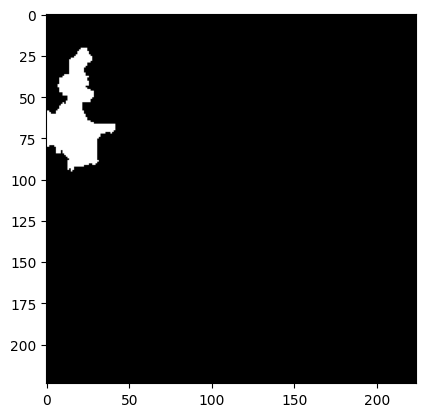

In [65]:
plt.imshow(mincut_segmented_masks[0], cmap='gray')

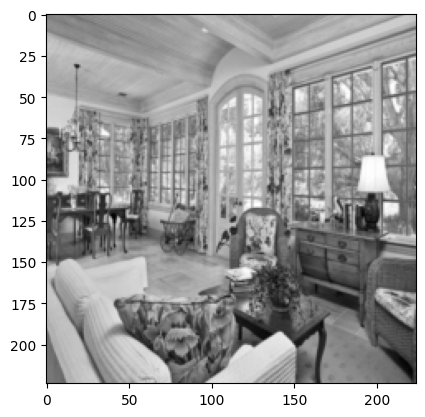

In [53]:
plt.imshow(batch['query_image'][0], cmap='gray')

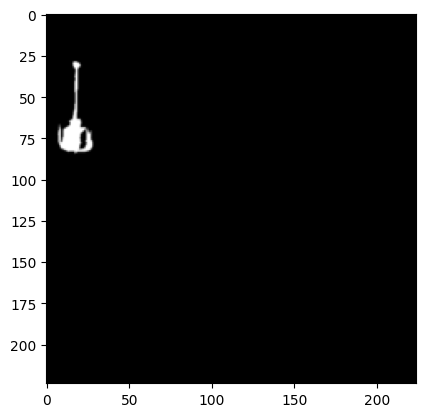

In [54]:
plt.imshow(batch['query_full_mask'][0], cmap='gray')

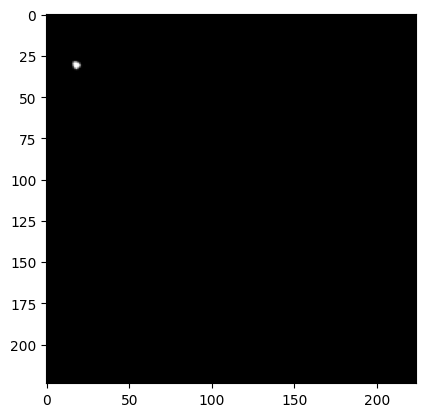

In [55]:
plt.imshow(batch['query_part_mask'][0], cmap='gray')

In [77]:
batch['query_part_mask'][0].numpy().shape

(224, 224)

In [79]:
val = np.unique(batch['query_part_mask'][0].numpy())
val

array([  0,   1,   2,   4,   5,   6,   7,  10,  16,  18,  21,  40,  72,
        79,  84,  88, 112, 117, 129, 153, 154, 176, 196, 200, 223, 225,
       247, 250, 255], dtype=uint8)

In [95]:
#torch.set_printoptions(threshold=10000)
print(batch['query_part_mask'][0])

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], dtype=torch.uint8)


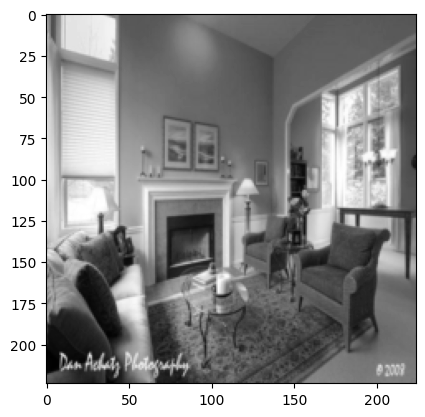

In [56]:
plt.imshow(batch['support_image'][0], cmap='gray')

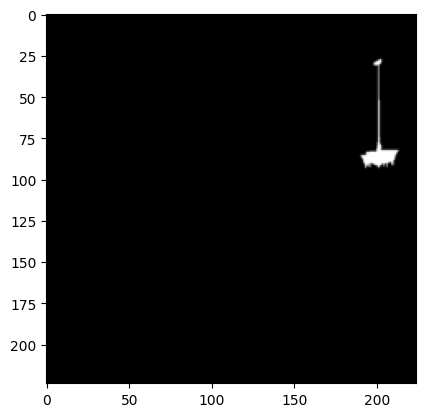

In [58]:
plt.imshow(batch['support_full_mask'][0], cmap='gray')

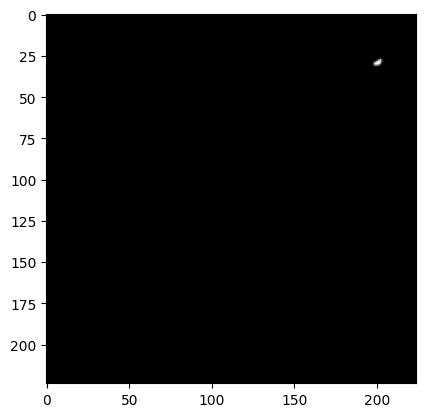

In [59]:
plt.imshow(batch['support_part_mask'][0], cmap='gray')

In [45]:
query_superpixel_features = torch.tensor(gt_output['superpixel_features'][real_sups_seg])
query_superpixel_features.shape

torch.Size([20, 1024])

In [46]:
adjacency_matrix = create_spatial_adjacency_matrix(gt_output['superpixel_labels'])
adjacency_matrix.shape

number of superpixel should be:	 784


torch.Size([784, 784])

In [48]:
adjacency_matrix = (adjacency_matrix + adjacency_matrix.T) / 2

In [50]:
adjacency_matrix.fill_diagonal_(0)
adjacency_matrix = (adjacency_matrix > 0.5).float()

In [51]:
data = Data(x=query_superpixel_features, adj=adjacency_matrix)

In [52]:
data

Data(x=[20, 1024], adj=[784, 784])